In [1]:
# Add the project root to Python path so we can import pyTT
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /das/home/barbaf_l/sdate to Python path


In [2]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def ssim2d_per_slice(
    vol_pred: torch.Tensor,         # shape (D, W, H), values ideally in [0,1]
    vol_gt: torch.Tensor,           # shape (D, W, H)
    data_range: float = 1.0,
    win_size: int = 11,             # must be odd, e.g. 7/9/11
    sigma: float = 1.5,
    K1: float = 0.01,
    K2: float = 0.03,
    device: torch.device = None,
    slice_batch: int = 64           # how many slices to process at once
):
    """
    Computes SSIM on each 2D slice (WxH), averages over pixels per slice,
    then returns the mean over all D slices. Also returns per-slice SSIMs.
    Works on CPU, CUDA, and Apple MPS.
    """
    assert vol_pred.shape == vol_gt.shape and vol_pred.ndim == 3, "Expected (D,W,H)"
    D, W, H = vol_pred.shape

    if win_size % 2 == 0:
        win_size += 1  # ensure odd
    if win_size > min(W, H):
        raise ValueError(f"win_size {win_size} larger than slice size {(W,H)}")

    # Pick device automatically if not given
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")

    x = vol_pred.to(device=device, dtype=torch.float32)
    y = vol_gt.to(device=device, dtype=torch.float32)

    # Build 2D Gaussian kernel (1x1)
    coords = torch.arange(win_size, device=device, dtype=torch.float32) - (win_size - 1) / 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = (g / g.sum()).reshape(-1, 1) @ (g / g.sum()).reshape(1, -1)
    kernel = (g / g.sum()).unsqueeze(0).unsqueeze(0).contiguous()  # [1,1,ks,ks]

    # Constants
    C1 = (K1 * data_range) ** 2
    C2 = (K2 * data_range) ** 2

    # Helpers
    pad = win_size // 2
    def conv2_same(z):  # z: [N,1,W,H]
        z = F.pad(z, (pad, pad, pad, pad), mode="reflect")
        return F.conv2d(z, kernel, groups=1)

    per_slice_vals = []
    for s0 in range(0, D, slice_batch):
        s1 = min(D, s0 + slice_batch)
        xs = x[s0:s1].unsqueeze(1)  # [n,1,W,H]
        ys = y[s0:s1].unsqueeze(1)

        mu_x = conv2_same(xs)
        mu_y = conv2_same(ys)
        mu_x2, mu_y2, mu_xy = mu_x**2, mu_y**2, mu_x * mu_y

        sigma_x2 = conv2_same(xs * xs) - mu_x2
        sigma_y2 = conv2_same(ys * ys) - mu_y2
        sigma_xy = conv2_same(xs * ys) - mu_xy

        num = (2 * mu_xy + C1) * (2 * sigma_xy + C2)
        den = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)
        ssim_map = num / (den + 1e-12)            # [n,1,W,H]
        ssim_slice = ssim_map.mean(dim=(1,2,3))   # [n]
        per_slice_vals.append(ssim_slice)

    per_slice_vals = torch.cat(per_slice_vals, dim=0)  # [D]
    mean_ssim = per_slice_vals.mean().item()
    return mean_ssim, per_slice_vals.detach().cpu()     # (float, tensor[D])

In [3]:
import torch
import numpy as np

# Set up device for accelerated computation on Apple Silicon
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"✅ MPS (Apple Silicon GPU) acceleration available and will be used")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ CUDA GPU acceleration available and will be used")
else:
    device = torch.device("cpu")
    print(f"ℹ️  Using CPU for computations (no GPU acceleration available)")


# Centralized Quality Metrics Function with Artifact Avoidance
def calculate_quality_metrics(original, reconstructed, crop_pixels=5, use_gpu=True):
    """
    Calculate PSNR and SSIM between two tensors using PyTorch, avoiding edge artifacts by cropping border pixels.
    
    Args:
        original: Original tensor (can be single image or batch)
        reconstructed: Reconstructed tensor (same shape as original)
        crop_pixels: Number of pixels to crop from each side (default: 5)
        use_gpu: Whether to use GPU acceleration if available (default: True)
    
    Returns:
        dict: Dictionary containing 'psnr' and 'ssim' values
    """
    # Choose device based on user preference and availability
    compute_device = device if use_gpu else torch.device("cpu")
    
    # Ensure tensors are float and move to compute device
    orig = original.float().to(compute_device)
    recon = reconstructed.float().to(compute_device)
    
    # Handle different tensor dimensions
    if orig.dim() == 2:  # Single 2D image
        orig = orig.unsqueeze(0)  # Add batch dimension
        recon = recon.unsqueeze(0)
    elif orig.dim() == 4:  # Video tensor (N, C, H, W)
        orig = orig.squeeze(1) if orig.shape[1] == 1 else orig.mean(dim=1)  # Remove channel or average RGB
        recon = recon.squeeze(1) if recon.shape[1] == 1 else recon.mean(dim=1)
    
    # Calculate PSNR using PyTorch
    mse = torch.mean((orig - recon) ** 2)
    if mse > 0:
        # Assume normalized input [0, 1] range
        max_val = torch.max(orig)
        psnr = 20 * torch.log10(max_val / torch.sqrt(mse))
    else:
        psnr = torch.tensor(float('inf'), device=compute_device)
    

    # B,C,H,W,D with values in [0,1]
    ssim, _ = ssim2d_per_slice(recon, orig, data_range=1.0, win_size=11, sigma=1.5, slice_batch=16)

    # Move results back to CPU for final output
    return {
        'psnr': psnr.cpu().item() if not torch.isinf(psnr) else float('inf'),
        'ssim': ssim,
        'mse': mse.cpu().item(),
        'cropped_shape': orig.shape,
        'crop_pixels': crop_pixels,
        'compute_device': str(compute_device)
    }

print(f"✅ Quality metrics function loaded with device: {device}")
print("   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5, use_gpu=True)")
print("   Features: PyTorch-based computation, GPU acceleration support, automatic edge cropping")
print(f"   GPU Acceleration: {'MPS (Apple Silicon)' if device.type == 'mps' else 'CUDA' if device.type == 'cuda' else 'Not available'}")

✅ CUDA GPU acceleration available and will be used
✅ Quality metrics function loaded with device: cuda
   Function: calculate_quality_metrics(original, reconstructed, crop_pixels=5, use_gpu=True)
   Features: PyTorch-based computation, GPU acceleration support, automatic edge cropping
   GPU Acceleration: CUDA


## Import Required Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from pathlib import Path
import lovely_tensors as lt
from PIL import Image
import glob
import re
from tqdm.auto import tqdm

# Import video compression utilities
from sdate.video_compression import encode_hevc_grayscale_10bit, decode_hevc_grayscale_10bit

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")
print("✅ Video compression utilities loaded:")
print("   - encode_hevc_grayscale_10bit")
print("   - decode_hevc_grayscale_10bit")

Libraries imported successfully!
✅ Video compression utilities loaded:
   - encode_hevc_grayscale_10bit
   - decode_hevc_grayscale_10bit


## Load and Explore TIFF File Sequence

This section loads a sequence of TIFF files from a folder and assembles them into a video tensor.
Each TIFF file represents one frame of the video sequence.

In [5]:
# Define the path to the TIFF sequence folder
# Example paths - adjust to your actual data location:
# data_path = Path('../data/tiff_sequence/')  
# data_path = Path('/path/to/your/tiff/folder/')  
data_path = Path('../data/ct_files/file_12_extracted')
data_path = Path('/das/home/barbaf_l/p22274/compression_paper/file_3_extracted')

# Check if the folder exists
if not data_path.exists():
    print(f"Error: Folder {data_path} does not exist!")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Looking for folder at: {data_path.absolute()}")
else:
    print(f"Folder found: {data_path.absolute()}")
    
    # List all TIFF files in the directory
    tiff_files = sorted(list(data_path.glob('*.tif')) + list(data_path.glob('*.tiff')))
    print(f"Found {len(tiff_files)} TIFF files")
    
    if len(tiff_files) > 0:
        print(f"First few files: {[f.name for f in tiff_files[:5]]}")
        print(f"Last few files: {[f.name for f in tiff_files[-5:]]}")
        
        # Analyze file naming pattern
        first_file = tiff_files[0].name
        print(f"\nAnalyzing file naming pattern from: {first_file}")
        
        # Try to extract naming pattern (e.g., PD1511_41_0001.tif)
        match = re.search(r'(.+?)_(\d+)\.(tiff?)', first_file)
        if match:
            prefix = match.group(1)
            print(f"Detected prefix pattern: '{prefix}_XXXX'")
        else:
            print("Could not detect standard naming pattern")
    else:
        print("❌ No TIFF files found in the directory")

Folder found: /das/home/barbaf_l/p22274/compression_paper/file_3_extracted
Found 751 TIFF files
First few files: ['MI04_020001.tif', 'MI04_020002.tif', 'MI04_020003.tif', 'MI04_020004.tif', 'MI04_020005.tif']
Last few files: ['MI04_020747.tif', 'MI04_020748.tif', 'MI04_020749.tif', 'MI04_020750.tif', 'MI04_020751.tif']

Analyzing file naming pattern from: MI04_020001.tif
Detected prefix pattern: 'MI04_XXXX'


In [6]:
# Load TIFF sequence and check data properties
def load_tiff_sequence(tiff_files, start_offset=0, max_frames=None, check_bit_depth=True):
    """
    Load a sequence of TIFF files into a video tensor.
    
    Args:
        tiff_files: List of Path objects pointing to TIFF files
        max_frames: Maximum number of frames to load (None for all)
        check_bit_depth: Whether to analyze bit depth requirements
    
    Returns:
        tuple: (video_tensor, min_val, max_val, dtype_info)
    """
    if max_frames is not None:
        tiff_files = tiff_files[start_offset:start_offset+max_frames]
    
    print(f"Loading {len(tiff_files)} TIFF files...")
    
    # Load first image to get dimensions and check data type
    first_img = Image.open(tiff_files[0])
    first_array = np.array(first_img)
    height, width = first_array.shape[:2]
    
    print(f"Image dimensions: {width} x {height}")
    print(f"First image dtype: {first_array.dtype}")
    print(f"First image shape: {first_array.shape}")
    print(f"First image range: [{first_array.min()}, {first_array.max()}]")
    
    # Determine if we can use 16-bit or need 32-bit
    if check_bit_depth:
        print("\n🔍 Analyzing bit depth requirements...")
        global_min = float('inf')
        global_max = float('-inf')
        
        # Sample some files to check range
        sample_indices = np.linspace(0, len(tiff_files)-1, min(20, len(tiff_files)), dtype=int)
        
        for idx in tqdm(sample_indices, desc="Sampling files for range analysis"):
            img = Image.open(tiff_files[idx])
            arr = np.array(img)
            global_min = min(global_min, arr.min())
            global_max = max(global_max, arr.max())
        
        print(f"Sampled range: [{global_min}, {global_max}]")
        
        # Determine optimal data type
        if global_max <= 65535 and global_min >= 0:
            optimal_dtype = torch.int16
            print("✅ Data fits in 16-bit signed integers")
        elif global_max <= 2147483647 and global_min >= -2147483648:
            optimal_dtype = torch.int32  
            print("⚠️  Data requires 32-bit integers")
        else:
            optimal_dtype = torch.float32
            print("⚠️  Data requires 32-bit float")
    else:
        optimal_dtype = torch.float32
        global_min, global_max = None, None
    
    # Initialize tensor
    if first_array.ndim == 2:  # Grayscale
        video_tensor = torch.zeros(len(tiff_files), height, width, dtype=optimal_dtype)
    else:  # Color - take first channel or convert to grayscale
        video_tensor = torch.zeros(len(tiff_files), height, width, dtype=optimal_dtype)
        print("⚠️  Color images detected - will convert to grayscale using first channel")
    
    # Load all images
    min_val = float('inf')
    max_val = float('-inf')
    
    for i, tiff_file in enumerate(tqdm(tiff_files, desc="Loading TIFF files")):
        img = Image.open(tiff_file)
        arr = np.array(img, dtype=np.int16)
        
        # Handle different image formats
        if arr.ndim == 3:  # Color image
            arr = arr[:, :, 0]  # Take first channel
        
        video_tensor[i] = torch.from_numpy(arr).to(optimal_dtype)
        
        # Track actual min/max
        min_val = min(min_val, arr.min())
        max_val = max(max_val, arr.max())
    
    dtype_info = {
        'original_dtype': first_array.dtype,
        'torch_dtype': optimal_dtype,
        'fits_16bit': max_val <= 65535 and min_val >= 0
    }
    
    return video_tensor, min_val, max_val, dtype_info

# Load the TIFF sequence
NUM_FRAMES = 300  # Limit for initial testing - adjust as needed
video_tensor_original, min_val, max_val, dtype_info = load_tiff_sequence(
    tiff_files, start_offset=150, max_frames=NUM_FRAMES, check_bit_depth=True
)

print(f"\n✅ TIFF sequence loaded successfully!")
print(f"Video tensor shape: {video_tensor_original.shape}")
print(f"Data type: {video_tensor_original.dtype}")
print(f"Value range: [{min_val}, {max_val}]")
print(f"Memory usage: {video_tensor_original.numel() * video_tensor_original.element_size() / 1e6:.2f} MB")
print(f"Bit depth analysis: {dtype_info}")

Loading 300 TIFF files...
Image dimensions: 1008 x 1900
First image dtype: uint16
First image shape: (1900, 1008)
First image range: [291, 2485]

🔍 Analyzing bit depth requirements...


Sampling files for range analysis:   0%|          | 0/20 [00:00<?, ?it/s]

Sampled range: [291, 2872]
✅ Data fits in 16-bit signed integers


Loading TIFF files:   0%|          | 0/300 [00:00<?, ?it/s]


✅ TIFF sequence loaded successfully!
Video tensor shape: torch.Size([300, 1900, 1008])
Data type: torch.int16
Value range: [288, 2928]
Memory usage: 1149.12 MB
Bit depth analysis: {'original_dtype': dtype('uint16'), 'torch_dtype': torch.int16, 'fits_16bit': True}


## Normalize Video Data

Normalize the video tensor to [0, 1] range for processing, similar to the H5 workflow.

In [7]:
# Normalize video tensor to [0, 1] range
print(f"🔄 Normalizing video tensor to [0, 1] range...")
print(f"Original range: [{min_val}, {max_val}]")

# Convert to float32 for normalization
video_tensor_original = video_tensor_original.float()
video_tensor_original -= min_val  # Shift to start at 0
video_tensor_original /= (max_val - min_val)  # Scale to [0, 1]
video_normalized = video_tensor_original

print(f"\n✅ Normalization completed:")
print(f"Normalized video tensor:")
print(f"  Shape: {video_normalized.shape}")
print(f"  Range: [{video_normalized.min():.6f}, {video_normalized.max():.6f}]")
print(f"  Data type: {video_normalized.dtype}")
print(f"  Memory usage: {video_normalized.numel() * video_normalized.element_size() / 1e6:.2f} MB")

print(f"\nOriginal video tensor (preserved):")
print(f"  Shape: {video_tensor_original.shape}")
print(f"  Range: [{min_val}, {max_val}]")
print(f"  Data type: {video_tensor_original.dtype}")
print(f"  Memory usage: {video_tensor_original.numel() * (video_tensor_original.element_size() / 2) / 1e6:.2f} MB")

# Display some basic statistics
print(f"\n📊 Normalized Data Statistics:")
print(f"  Mean: {video_normalized.mean():.6f}")
print(f"  Std: {video_normalized.std():.6f}")
print(f"  Min: {video_normalized.min():.6f}")
print(f"  Max: {video_normalized.max():.6f}")

🔄 Normalizing video tensor to [0, 1] range...
Original range: [288, 2928]

✅ Normalization completed:
Normalized video tensor:
  Shape: torch.Size([300, 1900, 1008])
  Range: [0.000000, 1.000000]
  Data type: torch.float32
  Memory usage: 2298.24 MB

Original video tensor (preserved):
  Shape: torch.Size([300, 1900, 1008])
  Range: [288, 2928]
  Data type: torch.float32
  Memory usage: 1149.12 MB

📊 Normalized Data Statistics:
  Mean: 0.315827
  Std: 0.112670
  Min: 0.000000
  Max: 1.000000


# Video Compression Analysis

In [8]:
# # Compute MSE differences between each frame and the first frame
# print("📊 Computing MSE differences between frames and first frame...")

# # Get the first frame as reference
# ref_frame = 0
# reference_frame = video_normalized[ref_frame].float()

# # Compute MSE for each frame compared to the first frame
# mse_differences = []
# frame_indices = []

# # Sample frames for computation (every frame for small datasets, or subsample for large ones)
# step_size = max(1, len(video_normalized) // 1000)  # Ensure we don't sample more than 1000 points
# print(f"Computing MSE for every {step_size}th frame...")

# for i in tqdm(range(0, len(video_normalized), step_size), desc="Computing MSE"):
#     if i == ref_frame:
#         continue  # Skip the reference frame itself
#     current_frame = video_normalized[i].float()
#     mse = torch.mean((current_frame - reference_frame) ** 2).item()
#     mse_differences.append(mse)
#     frame_indices.append(i)

# print(f"✅ Computed MSE for {len(mse_differences)} frames")

# # Create the plot
# plt.figure(figsize=(15, 8))
# plt.plot(frame_indices, mse_differences, 'b-', alpha=0.7, linewidth=1)
# plt.title('MSE Difference Between Each Frame and First Frame', fontsize=14, fontweight='bold')
# plt.xlabel('Frame Number')
# plt.ylabel('Mean Squared Error (MSE)')
# plt.grid(True, alpha=0.3)

# # Add statistics using PyTorch for consistency
# mean_mse = torch.tensor(mse_differences).mean().item()
# std_mse = torch.tensor(mse_differences).std().item()
# max_mse = torch.tensor(mse_differences).max().item()
# min_mse = torch.tensor(mse_differences).min().item()

# plt.axhline(y=mean_mse, color='r', linestyle='--', alpha=0.8, label=f'Mean MSE: {mean_mse:.2e}')
# plt.axhline(y=mean_mse + std_mse, color='orange', linestyle='--', alpha=0.6, label=f'Mean + 1σ: {mean_mse + std_mse:.2e}')
# plt.axhline(y=mean_mse - std_mse, color='orange', linestyle='--', alpha=0.6, label=f'Mean - 1σ: {mean_mse - std_mse:.2e}')

# plt.legend()
# plt.tight_layout()

# # Add text box with statistics
# stats_text = f'''Frame Difference Statistics:
# Frames analyzed: {len(mse_differences)}
# Step size: {step_size}
# Min MSE: {min_mse:.2e}
# Max MSE: {max_mse:.2e}
# Mean MSE: {mean_mse:.2e}
# Std MSE: {std_mse:.2e}
# Range: {max_mse - min_mse:.2e}'''

# plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
#          fontsize=10, verticalalignment='top', fontfamily='monospace',
#          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# plt.show()

# print(f"\n📈 MSE Analysis Summary:")
# print(f"   Minimum MSE: {min_mse:.2e}")
# print(f"   Maximum MSE: {max_mse:.2e}")
# print(f"   Mean MSE: {mean_mse:.2e}")
# print(f"   Standard Deviation: {std_mse:.2e}")
# print(f"   Dynamic Range: {max_mse/min_mse:.1f}x")

In [9]:
# Compress the video using HEVC 10-bit encoding
compressed_video_path = "tiff_demo_10b.mov"
print(f"🎬 Compressing video to: {compressed_video_path}")

# Encode with HEVC 10-bit grayscale
encode_hevc_grayscale_10bit(
    video_normalized, 
    compressed_video_path, 
    fps=30, 
    cq_hw=100,  # 100 is visually lossless quality
    force_software=True
)

# Decode the compressed video
reconstructed_video = decode_hevc_grayscale_10bit(compressed_video_path, device="cpu")
print(f"✅ Video compression completed")
print(f"Reconstructed video shape: {reconstructed_video.shape}")
print(f"Reconstructed video range: [{reconstructed_video.min():.6f}, {reconstructed_video.max():.6f}]")

🎬 Compressing video to: tiff_demo_10b.mov
📤  encoding 300 × 1008×1900 frames  (grayscale 10-bit HEVC)
⏭  force_software=True: skipping hardware encoder
✓ software encode (libx265) succeeded


/das/home/barbaf_l/sdate/sdate/video_compression/hevc_grayscale.py:194: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  vf = torch.from_numpy(v16).to(torch.float32) / 65535.0


✅ Video compression completed
Reconstructed video shape: torch.Size([300, 1900, 1008])
Reconstructed video range: [-0.499702, 0.499184]


In [10]:
# Load the compressed video for comparison
print("🎬 Loading Compressed Video for Quality Analysis")
print("=" * 60)

try:
    # Check if file exists and get size
    if os.path.exists(compressed_video_path):
        compressed_file_size = os.path.getsize(compressed_video_path)
        print(f"📁 Compressed file found: {compressed_video_path}")
        print(f"📏 Compressed file size: {compressed_file_size / 1e6:.2f} MB")
    else:
        raise FileNotFoundError(f"Compressed video file not found: {compressed_video_path}")
    
    # Calculate original data size
    original_tensor_size = video_normalized.numel() * video_normalized.element_size() / 2 # in bytes (assuming original was uint16)

    print(f"\n📊 Size Comparison:")
    print(f"   Original tensor size: {original_tensor_size / 1e6:.2f} MB")
    print(f"   Compressed file size: {compressed_file_size / 1e6:.2f} MB")
    
    # Calculate compression ratio
    compression_ratio = original_tensor_size / compressed_file_size
    space_savings = (1 - compressed_file_size / original_tensor_size) * 100
    
    print(f"   Compression ratio: {compression_ratio:.1f}:1")
    print(f"   Space savings: {space_savings:.1f}%")
    
    print(f"\n✅ Video loaded successfully for comparison")
    
except Exception as e:
    print(f"❌ Error loading compressed video: {e}")
    print("   Make sure the video was encoded successfully")
    reconstructed_video = None

🎬 Loading Compressed Video for Quality Analysis
📁 Compressed file found: tiff_demo_10b.mov
📏 Compressed file size: 53.35 MB

📊 Size Comparison:
   Original tensor size: 1149.12 MB
   Compressed file size: 53.35 MB
   Compression ratio: 21.5:1
   Space savings: 95.4%

✅ Video loaded successfully for comparison
The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [11]:
# Test GPU acceleration performance
if reconstructed_video is not None:
    print("🚀 Testing GPU Acceleration Performance")
    print("=" * 60)
    
    skip = 10
    test_original = video_normalized[::skip]
    test_reconstructed = reconstructed_video[::skip]

    # Time CPU computation
    import time
    
    print(f"Skipping {skip} frames...")
    
    # CPU timing
    start_time = time.time()
    metrics = calculate_quality_metrics(test_original, test_reconstructed, use_gpu=False)
    cpu_time = time.time() - start_time

    # Extract results
    psnr_value = metrics['psnr']
    ssim_value = metrics['ssim']
    mse = metrics['mse']
    
    print(f"\nGPU Results:")
    print(f"  PSNR: {psnr_value:.2f} dB")
    print(f"  SSIM: {ssim_value:.4f}")
    print(f"  MSE: {mse:.6e}")
    print(f"  Time taken: {cpu_time:.4f} seconds")

    min_frames = min(video_tensor_original.shape[0], reconstructed_video.shape[0])
    min_height = min(video_tensor_original.shape[1], reconstructed_video.shape[1])
    min_width = min(video_tensor_original.shape[2], reconstructed_video.shape[2])
    
    # Data usage efficiency
    bits_per_pixel_original = (original_tensor_size * 8) / (min_frames * min_height * min_width)
    bits_per_pixel_compressed = (compressed_file_size * 8) / (min_frames * min_height * min_width)


🚀 Testing GPU Acceleration Performance
Skipping 10 frames...

GPU Results:
  PSNR: 20.18 dB
  SSIM: 0.9559
  MSE: 9.319153e-03
  Time taken: 14.2045 seconds


📊 Visualizing Compression Results


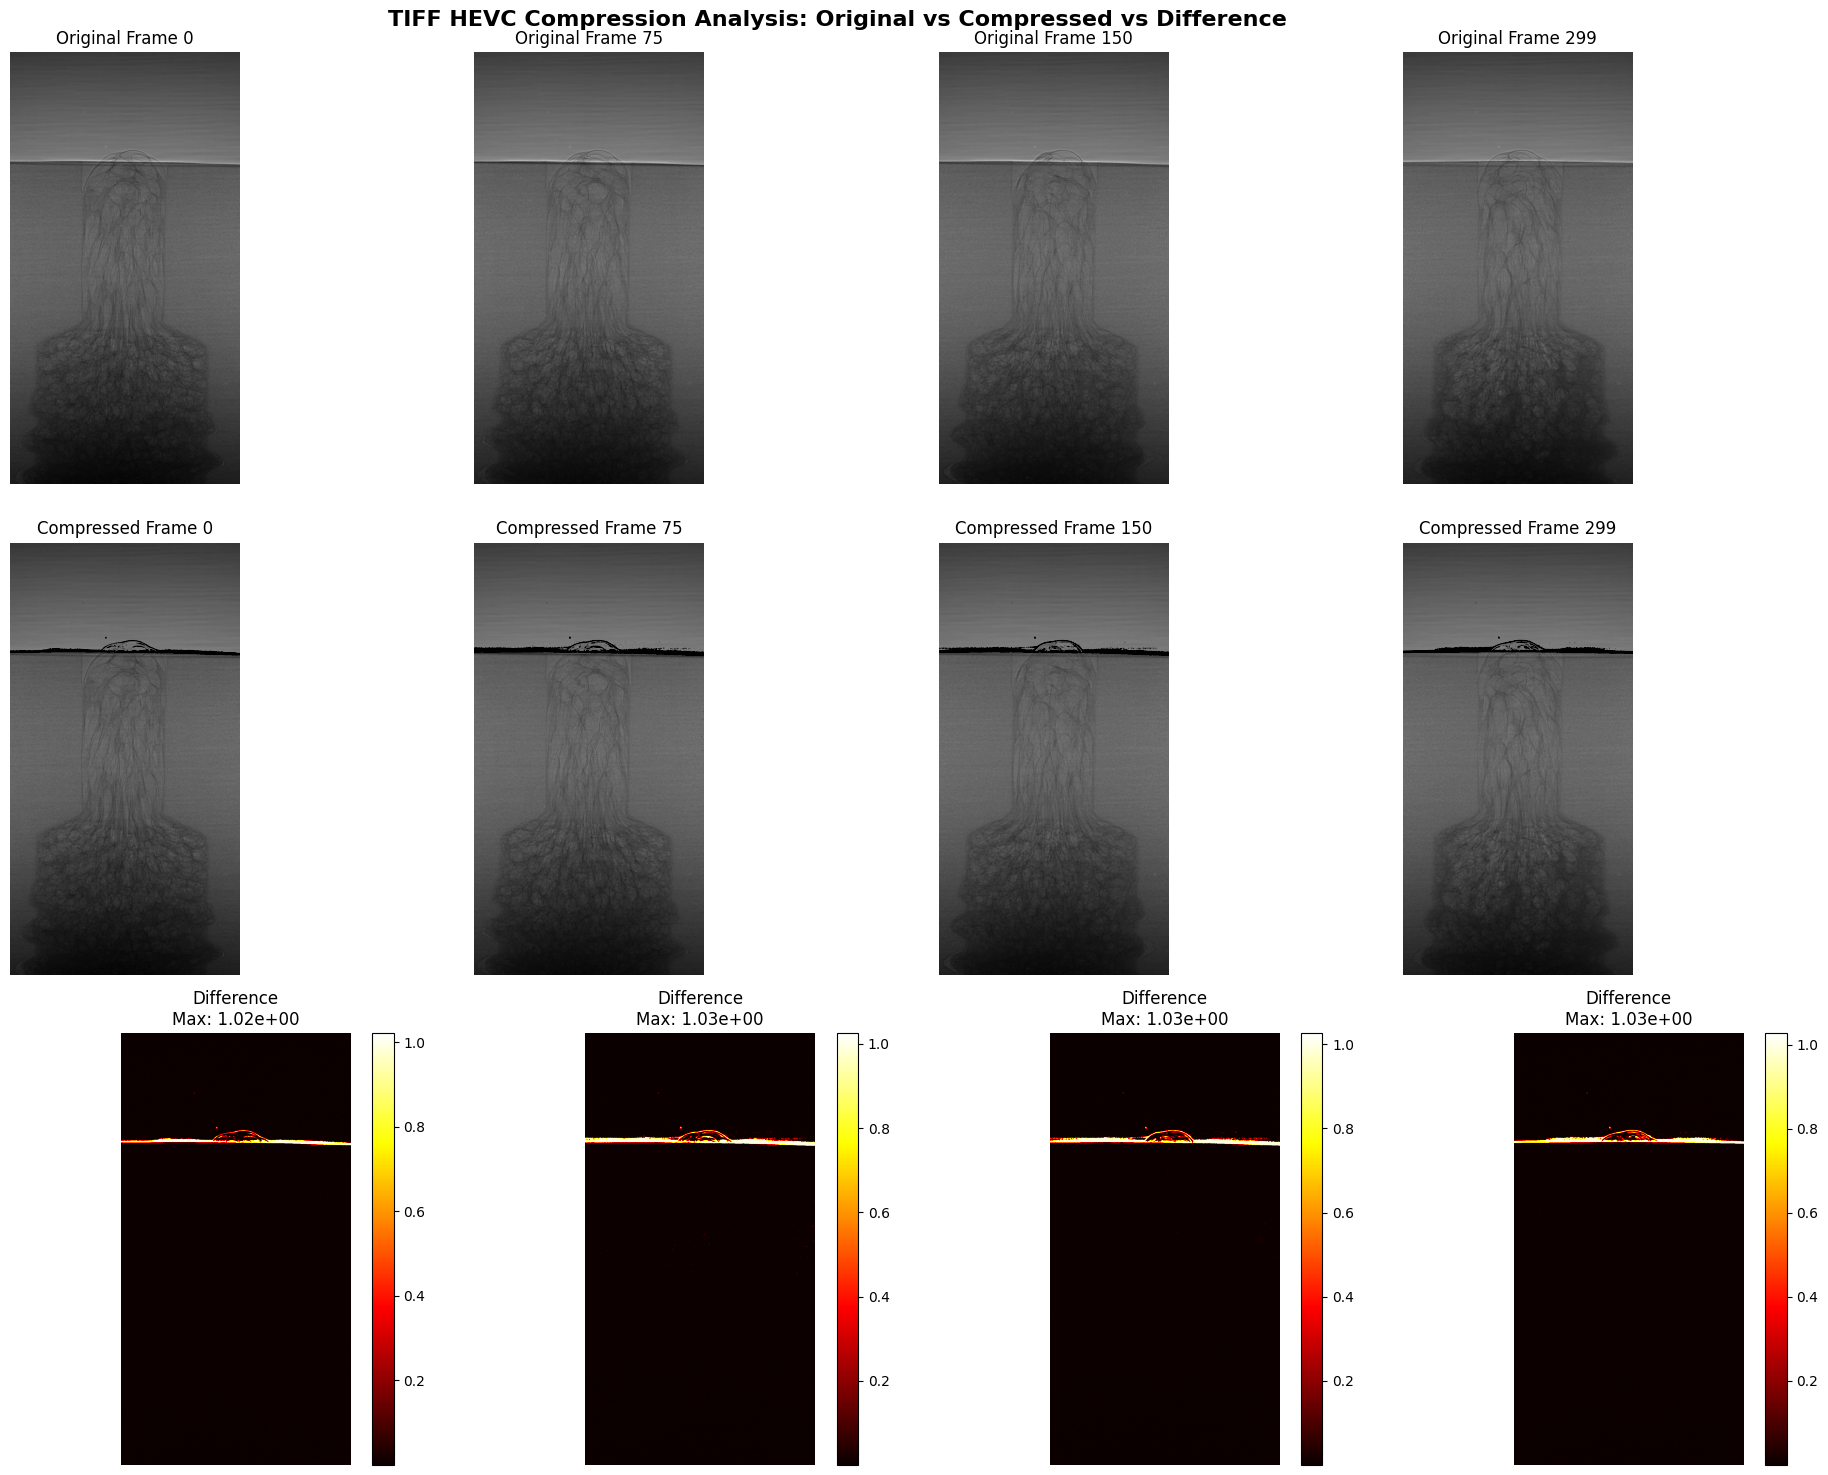


📋 Compression Summary:
Source................... TIFF Sequence
Original Size (MB)....... 1149.12
Compressed Size (MB)..... 53.35
Compression Ratio........ 21.5:1
Space Savings............ 95.4%
PSNR (dB)................ 20.18
SSIM..................... 0.955889
Bits/Pixel Original...... 16.00
Bits/Pixel Compressed.... 0.74

✅ Analysis completed! Summary data available in 'df_summary' variable


In [12]:
# Visualize compression results
if reconstructed_video is not None:
    print("📊 Visualizing Compression Results")
    print("=" * 50)
    
    # Select frames for visualization
    comparison_frames = [0, min_frames // 4, min_frames // 2, min_frames - 1]
    
    fig, axes = plt.subplots(3, len(comparison_frames), figsize=(5*len(comparison_frames), 15))
    fig.suptitle('TIFF HEVC Compression Analysis: Original vs Compressed vs Difference', 
                 fontsize=16, fontweight='bold')
    
    for i, frame_idx in enumerate(comparison_frames):
        if frame_idx < min_frames:
            original_frame = video_normalized[frame_idx]
            compressed_frame = reconstructed_video[frame_idx]
            difference = torch.abs(original_frame - compressed_frame)
            
            # Original
            axes[0, i].imshow(original_frame.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[0, i].set_title(f'Original Frame {frame_idx}')
            axes[0, i].axis('off')
            
            # Compressed
            axes[1, i].imshow(compressed_frame.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[1, i].set_title(f'Compressed Frame {frame_idx}')
            axes[1, i].axis('off')
            
            # Difference
            im = axes[2, i].imshow(difference.cpu().numpy(), cmap='hot')
            axes[2, i].set_title(f'Difference\nMax: {difference.max():.2e}')
            axes[2, i].axis('off')
            plt.colorbar(im, ax=axes[2, i], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    summary_data = {
        'Source': 'TIFF Sequence',
        'Original Size (MB)': f"{original_tensor_size / 1e6:.2f}",
        'Compressed Size (MB)': f"{compressed_file_size / 1e6:.2f}",
        'Compression Ratio': f"{compression_ratio:.1f}:1",
        'Space Savings': f"{space_savings:.1f}%",
        'PSNR (dB)': f"{psnr_value:.2f}",
        'SSIM': f"{ssim_value:.6f}",
        'Bits/Pixel Original': f"{bits_per_pixel_original:.2f}",
        'Bits/Pixel Compressed': f"{bits_per_pixel_compressed:.2f}"
    }
    
    # Display summary
    print(f"\n📋 Compression Summary:")
    print("=" * 50)
    for key, value in summary_data.items():
        print(f"{key:.<25} {value}")
    
    # Create summary dataframe for easy export if needed
    import pandas as pd
    df_summary = pd.DataFrame([summary_data])
    print(f"\n✅ Analysis completed! Summary data available in 'df_summary' variable")
    
else:
    print("❌ Cannot visualize results - reconstructed video not available")